# 03. 멀티 에이전트 협업 (Multi-Agent Collaboration)

> Supervisor 없이 에이전트끼리 직접 메시지를 주고받는 게 Collaboration 패턴이에요. `FINAL ANSWER` 종료 신호와 양방향 그래프로 동등한 협업을 구현해요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. **중앙 조정자 없는 협업** 아키텍처를 이해하고, Supervisor 패턴과의 차이를 설명할 수 있어요
2. `make_system_prompt()` 헬퍼 함수로 협업 지시사항이 포함된 시스템 프롬프트를 생성할 수 있어요
3. `router` 함수로 `"FINAL ANSWER"` 키워드를 감지해 그래프 종료 흐름을 구현할 수 있어요
4. `MessagesState`와 `add_conditional_edges`로 에이전트 간 양방향 순환 그래프를 구성할 수 있어요

## 사전 지식

- 이전 노트북: `02-Supervisor.ipynb`에서 배운 Supervisor 패턴, `create_agent`, 핸드오프
- `StateGraph`, `MessagesState`, `add_messages` 리듀서 기초 (Part 2 참고)
- `create_agent`로 에이전트 생성하는 방법 (Part 5 참고)

## 멀티 에이전트 협업이란?

이전 노트북에서 배운 **Supervisor 패턴**은 중앙 조정자(Supervisor)가 모든 워커를 관리했어요.
이번에는 Supervisor 없이 에이전트들이 **직접 서로 메시지를 주고받으며 협력**하는 패턴을 살펴볼게요.

> 🎯 **강의 포인트**: Supervisor 패턴이 **위에서 아래로 지시하는 군대식 조직**이라면, 협업 패턴은 **래퍼와 비트메이커의 콜라보**와 같아요. 래퍼(Researcher)가 가사(데이터)를 쓰면 비트메이커(Chart Generator)가 비트(차트)를 만들고, 완성될 때까지 핑퐁하다가 "이거다!" 하면 "FINAL ANSWER"로 마무리해요. 감독자 없이도 서로의 결과를 보고 자율적으로 협력하는 구조예요.

이 패턴은 **AutoGen 논문**에서 영감을 받았어요. 에이전트들이 하나의 공유 대화 스레드에서 협력하며, 자신의 역할이 끝나면 파트너에게 배턴을 넘겨요.

### Supervisor 패턴 vs 협업 패턴 비교

| 항목 | Supervisor 패턴 | 협업 패턴 |
|------|-----------------|----------|
| **조정자** | Supervisor 에이전트 존재 | 없음 (분산 제어) |
| **통신** | Supervisor ↔ Worker (단방향) | 에이전트 ↔ 에이전트 (양방향) |
| **종료 조건** | Supervisor가 판단 | `"FINAL ANSWER"` 키워드 감지 |
| **상태 공유** | Supervisor가 라우팅 | `MessagesState`로 직접 공유 |
| **비유** | 군대식 (명령-복종) | 밴드 (자율 협업) |
| **적합한 상황** | 명확한 위계가 필요할 때 | 긴밀한 협력, 반복 개선이 필요할 때 |

> 🔑 **핵심 개념**: 협업 패턴에서 에이전트들은 **공유 메시지 큐(MessagesState)**를 통해 소통해요. 각 에이전트는 이전 메시지들을 모두 볼 수 있고, 자신의 차례가 되면 응답을 추가해요. Supervisor가 없어도 `"FINAL ANSWER"` 키워드로 작업 완료를 신호할 수 있어요.

### 이번 실습 시나리오

두 에이전트가 협력해서 **한국 경제 데이터 시각화**를 만들어요:
- **Researcher**: Tavily로 웹 검색, 데이터 수집
- **Chart Generator**: Python 코드 실행, 차트 생성

### 아키텍처 다이어그램

```mermaid
flowchart TD
    User([사용자 요청<br/>User Request])
    Researcher[Researcher 에이전트<br/>웹 검색 및 데이터 수집]
    ChartGen[Chart Generator 에이전트<br/>Python 코드 실행 및 차트 생성]
    Router1{라우터<br/>FINAL ANSWER?}
    Router2{라우터<br/>FINAL ANSWER?}
    End([작업 완료<br/>End])

    User --> Researcher
    Researcher --> Router1
    Router1 -- FINAL ANSWER --> End
    Router1 -- continue --> ChartGen
    ChartGen --> Router2
    Router2 -- FINAL ANSWER --> End
    Router2 -- continue --> Researcher

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef decision fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef output fill:#f8d7da,stroke:#dc3545,color:#721c24

    class User input
    class Researcher,ChartGen process
    class Router1,Router2 decision
    class End output
```

> ⚠️ **자주 하는 실수**: 위 다이어그램의 **양방향 순환 구조**에 주목해 주세요. Researcher → ChartGen → Researcher로 반복할 수 있어요. `recursion_limit`을 설정하지 않으면 에이전트들이 무한히 대화를 주고받으며 API 비용이 치솟을 수 있어요!

## 환경 설정

In [1]:
# 환경 변수 로드 (.env 파일에서 API 키를 가져와요)
from dotenv import load_dotenv

load_dotenv(override=True)
# 환경 변수 로드 완료

True

In [2]:
# LangSmith 추적 설정 (실행 흐름을 시각화해서 확인할 수 있어요)
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-09-Multi-Agent-Collaboration"

# LangSmith 추적 설정 완료

## 1. 공유 상태(MessagesState) 정의

협업 패턴의 핵심은 **공유 상태**예요. 모든 에이전트가 동일한 메시지 목록을 보고, 자신의 응답을 추가해요.

`MessagesState`는 내부적으로 다음과 같이 정의돼요:

```python
class MessagesState(TypedDict):
    messages: Annotated[list, add_messages]  # add_messages 리듀서 자동 적용
```

> 🔑 **핵심 개념**: `add_messages` 리듀서 덕분에 각 에이전트가 반환하는 메시지가 **기존 목록에 추가**되어요. 에이전트가 `{"messages": [new_msg]}`를 반환하면 이전 메시지들은 그대로 유지되고 새 메시지만 쌓여요. 이것이 협업 대화 스레드를 만드는 핵심 메커니즘이에요.

In [3]:
# ---------------------------------------------------
# 공유 상태 정의
# ---------------------------------------------------
# MessagesState: add_messages 리듀서가 내장된 공유 메시지 상태
# 에이전트가 메시지를 추가하면 자동으로 기존 목록에 누적돼요
from langgraph.graph import MessagesState

# MessagesState 구조 확인
# MessagesState 사용 준비 완료
print()
# 내부 구조:
#   class MessagesState(TypedDict):
#       messages: Annotated[list, add_messages]
print()
# -> add_messages 리듀서: 새 메시지를 기존 목록에 자동 추가

## 2. 도구(Tool) 정의

두 에이전트가 사용할 전문 도구를 정의해요.

| 도구 | 사용 에이전트 | 역할 |
|------|-------------|------|
| `TavilySearch` | Researcher | 인터넷 검색으로 데이터 수집 |
| `python_repl_tool` | Chart Generator | Python 코드 실행으로 차트 생성 |

> ⚠️ **자주 하는 실수**: `python_repl_tool`에서 `exec(code, {})` 빈 딕셔너리로 실행하면 모듈 import가 안 돼요. `exec(code)` 또는 글로벌 네임스페이스를 공유해야 matplotlib 등이 정상 동작해요. 아래 코드는 빈 컨텍스트 문제를 우회하기 위해 코드를 직접 실행하는 방식을 사용해요.

In [4]:
# ---------------------------------------------------
# 도구 정의
# ---------------------------------------------------
# TavilySearch: 웹 검색 도구 (Researcher 에이전트가 사용)
# python_repl_tool: Python 코드 실행 도구 (Chart Generator 에이전트가 사용)
import io
import sys
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain.tools import tool

# Tavily 검색 도구 초기화 (최대 5개 결과 반환)
tavily_tool = TavilySearch(max_results=5)


def run_python_code(code: str) -> str:
    """Python 코드를 실행하고 stdout 출력을 캡처해요."""
    old_stdout = sys.stdout
    sys.stdout = buffer = io.StringIO()
    try:
        # exec: 문자열로 받은 Python 코드를 실행해요
        # 글로벌 네임스페이스 공유로 import가 정상 동작해요
        exec(code)  # noqa: S102
    except Exception as e:
        sys.stdout = old_stdout
        return f"Error: {repr(e)}"
    sys.stdout = old_stdout
    return buffer.getvalue()


@tool
def python_repl_tool(
    code: Annotated[str, "실행할 Python 코드예요. 출력을 보려면 print(...)를 사용하세요."],
):
    """Python 코드를 실행해요. 차트 생성, 데이터 분석 등에 사용할 수 있어요."""
    try:
        result = run_python_code(code)
    except BaseException as e:
        return f"코드 실행 실패. 오류: {repr(e)}"

    # 실행 성공 시 결과 반환 + FINAL ANSWER 힌트 추가
    result_str = f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"
    return (
        result_str
        + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )


# 도구 정의 완료
#   - tavily_tool: 웹 검색 (Researcher 전용)
#   - python_repl_tool: Python 코드 실행 (Chart Generator 전용)

## 3. 시스템 프롬프트 헬퍼 함수

협업 패턴에서는 각 에이전트가 다음 사항을 알아야 해요:
1. 나는 팀의 일원이다
2. 내가 모든 걸 해결 못해도 괜찮다 — 파트너가 이어받는다
3. 최종 답변이 준비되면 `"FINAL ANSWER"`를 앞에 붙여야 한다

`make_system_prompt()` 함수는 이 공통 협업 지시사항에 역할별 설명을 추가해줘요.

> 💡 **실무 팁**: `"FINAL ANSWER"` 패턴은 멀티에이전트 협업에서 가장 널리 사용되는 종료 신호 방식이에요. 라우터 함수가 이 키워드를 감지해서 그래프를 종료해요. 종료 키워드를 바꾸고 싶다면 `make_system_prompt`와 `router`를 함께 수정하면 돼요.

In [5]:
# ---------------------------------------------------
# 시스템 프롬프트 헬퍼 함수
# ---------------------------------------------------
# make_system_prompt: 협업 에이전트 공통 지시사항 + 역할별 설명을 합쳐요
# - 공통 지시: 팀원임을 인지, FINAL ANSWER 신호 방법 안내
# - suffix: 에이전트별 전문 영역 설명 (호출 시 전달)

def make_system_prompt(suffix: str) -> str:
    """협업 에이전트를 위한 시스템 프롬프트를 생성하는 헬퍼 함수예요."""
    return (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools"
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{suffix}"
    )


# 적용 예시 확인
example_prompt = make_system_prompt("You can only do research.")
# make_system_prompt() 적용 결과 (앞 200자):
# --------------------------------------------------
print(example_prompt[:200])
# ...
print()
# -> 공통 협업 지시사항 + 역할별 설명(suffix)이 합쳐졌어요

You are a helpful AI assistant, collaborating with other assistants. Use the provided tools to progress towards answering the question. If you are unable to fully answer, that's OK, another assistant 



## 4. 에이전트 생성

이제 두 협업 에이전트를 만들어요.

### 왜 HumanMessage로 변환할까요?

각 에이전트의 노드 함수는 에이전트 응답의 마지막 메시지를 `HumanMessage`로 변환해요:

```python
result = research_agent.invoke(state)
last_message = HumanMessage(
    content=result["messages"][-1].content,
    name="researcher"  # 발신자 이름 표시
)
```

> 🔑 **핵심 개념**: `HumanMessage`로 변환하는 이유는 파트너 에이전트가 이 메시지를 **사용자의 요청**처럼 자연스럽게 받아들이도록 하기 위해서예요. `name="researcher"`는 "이 메시지가 연구원이 보낸 것"이라고 표시해요. `AIMessage`가 두 개 연속으로 오면 일부 모델이 혼동할 수 있어요.

> ⚠️ **자주 하는 실수**: 에이전트 노드에서 `return result`라고 전체 결과를 그대로 반환하면 안 돼요. 에이전트 내부의 중간 메시지들(도구 호출, 도구 응답 등)이 모두 상태에 추가되어 공유 메시지 큐가 오염돼요. 파트너에게 전달할 **최종 메시지만** 선택해서 반환해야 깔끔한 협업이 가능해요.

In [6]:
# ---------------------------------------------------
# Research Agent 생성
# ---------------------------------------------------
# 역할: TavilySearch로 웹에서 데이터 검색
# 파트너: Chart Generator (데이터를 넘겨주는 대상)
from langchain.agents import create_agent
from langchain.messages import HumanMessage

# Research Agent 생성
# - 도구: tavily_tool (웹 검색)
# - 역할: 데이터 조사만 담당, 차트 생성은 파트너에게 맡김
research_agent = create_agent(
    model="openai:gpt-4o-mini",  # 기본 모델: gpt-4o-mini (비용 효율적)
    tools=[tavily_tool],
    system_prompt=make_system_prompt(
        "You can only do research. "
        "You are working with a chart generator colleague."
    ),
)


def research_node(state: MessagesState) -> MessagesState:
    """Research Agent 노드 함수예요."""
    # Research Agent 실행 (공유 상태 전달)
    result = research_agent.invoke(state)

    # 마지막 메시지를 HumanMessage로 변환
    # name="researcher": 어떤 에이전트가 보낸 메시지인지 표시해요
    last_message = HumanMessage(
        content=result["messages"][-1].content,
        name="researcher",  # 발신자 이름 기록
    )
    return {
        # 최종 메시지만 반환 → 공유 상태에 추가됨
        "messages": [last_message],
    }


# Research Agent 생성 완료
#   - 도구: TavilySearch (웹 검색)
#   - 노드 함수: research_node
#   - 메시지 발신자 이름: 'researcher'

In [7]:
# ---------------------------------------------------
# Chart Generator Agent 생성
# ---------------------------------------------------
# 역할: Python 코드로 데이터를 차트로 시각화
# 파트너: Researcher (시각화할 데이터를 받는 대상)

# 차트 생성 에이전트용 시스템 프롬프트 (OS별 한글 폰트 설정 포함)
chart_generator_system_prompt = """
You can only generate charts. You are working with a researcher colleague.
When generating matplotlib charts with Korean labels, always include the following font setup before plotting.

##### Korean font setup #####
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

preferred_fonts = ["AppleGothic", "NanumGothic", "Malgun Gothic", "Arial Unicode MS"]
available_fonts = {font.name for font in fm.fontManager.ttflist}
for font_name in preferred_fonts:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break
else:
    # If no Korean font is installed, use English labels to avoid glyph warnings.
    use_english_labels = True

plt.rcParams["axes.unicode_minus"] = False
"""

# Chart Generator Agent 생성
# - 도구: python_repl_tool (Python 코드 실행)
# - 역할: 데이터 시각화만 담당, 데이터 조사는 파트너에게 맡김
chart_agent = create_agent(
    model="openai:gpt-4o-mini",  # 기본 모델: gpt-4o-mini
    tools=[python_repl_tool],
    system_prompt=make_system_prompt(chart_generator_system_prompt),
    name="chart_generator",
)


def chart_node(state: MessagesState) -> MessagesState:
    """Chart Generator Agent 노드 함수예요."""
    # Chart Generator Agent 실행 (공유 상태 전달)
    result = chart_agent.invoke(state)

    # 마지막 메시지를 HumanMessage로 변환
    # name="chart_generator": 차트 생성 에이전트가 보낸 메시지임을 표시
    last_message = HumanMessage(
        content=result["messages"][-1].content,
        name="chart_generator",  # 발신자 이름 기록
    )
    return {
        # 최종 메시지만 반환 → 공유 상태에 추가됨
        "messages": [last_message],
    }


# Chart Generator Agent 생성 완료
#   - 도구: python_repl_tool (Python 코드 실행)
#   - 노드 함수: chart_node
#   - 메시지 발신자 이름: 'chart_generator'

## 5. 라우터(Router) 함수 정의

라우터 함수는 각 에이전트 실행 후 **다음 단계를 결정**해요:
- 메시지에 `"FINAL ANSWER"`가 있으면 → 그래프 종료
- 없으면 → 파트너 에이전트로 전달

```mermaid
flowchart LR
    A[에이전트 실행 완료] --> B{마지막 메시지에<br>'FINAL ANSWER' 포함?}
    B -- Yes --> C[END: 그래프 종료]
    B -- No --> D[continue: 파트너 에이전트로]

    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef decision fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef output fill:#f8d7da,stroke:#dc3545,color:#721c24
    classDef success fill:#d4edda,stroke:#28a745,color:#155724

    class A process
    class B decision
    class C output
    class D success
```

> 💡 **실무 팁**: 라우터 함수에서 `isinstance(content, list)` 처리가 중요해요. Anthropic 모델은 응답을 텍스트 블록 리스트로 반환할 수 있어요. OpenAI는 문자열로 반환하지만, 멀티 모달이나 다른 모델 사용 시 대비해서 리스트 처리를 넣어두는 것이 안전해요.

In [8]:
# ---------------------------------------------------
# 라우터 함수 정의
# ---------------------------------------------------
# 역할: 에이전트 출력을 보고 다음 노드를 결정해요
# - "FINAL ANSWER" 감지 → END (종료)
# - 그 외 → "continue" (파트너에게 전달)
from langgraph.graph import END


def router(state: MessagesState):
    """라우터 함수: 에이전트 출력에 따라 다음 노드를 결정해요."""
    messages = state["messages"]
    last_message = messages[-1]
    content = last_message.content

    # content가 list(content block 형태)인 경우 텍스트만 추출해요
    # Anthropic 모델은 [{"type": "text", "text": "..."}] 형태로 반환할 수 있어요
    if isinstance(content, list):
        content = " ".join(
            block.get("text", "") for block in content if isinstance(block, dict)
        )

    if "FINAL ANSWER" in content:
        # 작업이 완료된 신호 → 그래프 종료
        return END

    # 아직 작업이 남아 있음 → 파트너 에이전트로 전달
    return "continue"


# 라우터 동작 테스트
from langchain.messages import HumanMessage as HM

test_state_final = {"messages": [HM(content="FINAL ANSWER: 분석 완료")]}
test_state_continue = {"messages": [HM(content="데이터를 수집했어요. 차트를 그려주세요.")]}

# 라우터 함수 테스트
# ----------------------------------------
print(f"'FINAL ANSWER' 포함 → {router(test_state_final)}")
print(f"'FINAL ANSWER' 없음 → {router(test_state_continue)}")

'FINAL ANSWER' 포함 → __end__
'FINAL ANSWER' 없음 → continue


## 6. 협업 그래프 구성

이제 두 에이전트를 연결하는 협업 그래프를 만들어요.

### 그래프 구성 핵심

| 구성 요소 | 코드 | 설명 |
|-----------|------|------|
| **노드** | `add_node("researcher", research_node)` | 에이전트를 노드로 등록 |
| **조건부 엣지** | `add_conditional_edges` | 라우터 결과에 따라 분기 |
| **체크포인터** | `MemorySaver()` | 상태 저장 (Time Travel 가능) |
| **재귀 제한** | `recursion_limit=10` | 무한 루프 방지 |

> 🎯 **강의 포인트**: `recursion_limit`은 협업 패턴에서 **무한 루프 방지의 마지막 보루**예요. 두 에이전트가 서로 `"continue"`를 계속 반환하면 그래프가 멈추지 않아요. `recursion_limit`을 낮게 설정하면 빨리 실패하고, 높게 설정하면 더 많은 왕복이 가능해요. 실무에서는 작업 복잡도에 따라 조정해요.

In [9]:
# ---------------------------------------------------
# 협업 그래프 구성
# ---------------------------------------------------
# 구조:
# START → researcher → [라우터] → chart_generator → [라우터] → researcher (반복)
#                    ↘ END                         ↘ END
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

# StateGraph 생성 (MessagesState를 공유 상태로 사용)
workflow = StateGraph(MessagesState)

# 노드 추가
# - "researcher": Research Agent 노드
# - "chart_generator": Chart Generator Agent 노드
workflow.add_node("researcher", research_node)
workflow.add_node("chart_generator", chart_node)

# 조건부 엣지 추가 (researcher 노드에서)
# - "continue" → chart_generator 노드로 전달
# - END → 그래프 종료
workflow.add_conditional_edges(
    "researcher",
    router,
    {"continue": "chart_generator", END: END},
)

# 조건부 엣지 추가 (chart_generator 노드에서)
# - "continue" → researcher 노드로 다시 전달 (양방향 순환!)
# - END → 그래프 종료
workflow.add_conditional_edges(
    "chart_generator",
    router,
    {"continue": "researcher", END: END},
)

# 시작점: START → researcher (Research Agent가 먼저 실행)
workflow.add_edge(START, "researcher")

# 그래프 컴파일 (MemorySaver: 상태 저장 기능)
app = workflow.compile(checkpointer=MemorySaver())

# 협업 그래프 구성 완료
#   - 노드: researcher, chart_generator
#   - 엣지: 양방향 조건부 엣지 (라우터 함수)
#   - 체크포인터: MemorySaver (상태 저장)

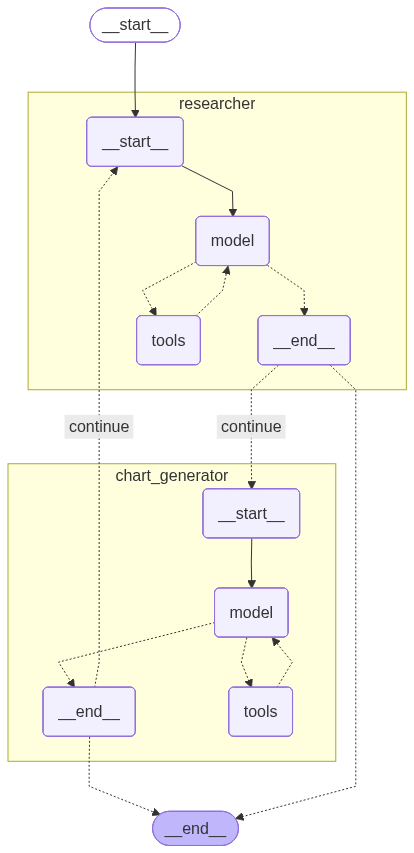

In [10]:
# 그래프 흐름: START → researcher → [라우터] → chart_generator → [라우터] → researcher → ... → END
# researcher: Tavily로 웹 검색하여 데이터를 수집해요
# chart_generator: Python 코드를 실행하여 차트를 생성해요
# 라우터: "FINAL ANSWER" 키워드 감지 시 END, 없으면 파트너 에이전트로 전달해요
# 양방향 순환: 두 에이전트가 번갈아 협업하며 recursion_limit으로 무한 루프를 방지해요
from IPython.display import Image, display

# draw_mermaid_png: 그래프를 Mermaid 형식으로 시각화해요
# xray=True: 서브그래프 내부 구조도 함께 표시
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

## 7. 협업 그래프 실행

이제 두 에이전트가 협력해서 한국 1인당 GDP 추이 차트를 만들어볼게요!

실행 흐름:
1. **Researcher**: "2010~2025 한국 1인당 GDP 데이터" 웹 검색
2. **Chart Generator**: 검색 결과를 받아 matplotlib으로 차트 생성
3. 차트 생성 완료 후 `"FINAL ANSWER"` 신호 → 종료

### config 설정

```python
config = RunnableConfig(
    recursion_limit=10,  # 최대 10번 왕복 허용
    configurable={"thread_id": "thread-1"}  # 대화 스레드 ID
)
```

> 💡 **실무 팁**: `recursion_limit`을 너무 높게 설정하면 API 비용이 급증해요. 협업 에이전트 시스템에서는 보통 3~5번 왕복이면 대부분의 작업이 완료돼요. 처음 개발 시에는 낮은 값(5~7)으로 시작해서 필요한 경우 늘려가요.


--- [researcher] ---
I cannot create a graph directly, but I can provide you with the data in a format that you can easily visualize using a charting tool or software. Here’s the data for South Korea's GDP per capita from 2010 to 2025:

- 2010: $24,070
- 2011: $26,180
- 2012: $26,600
- 2013: $28,450
- 2014: $30,670
- 20...


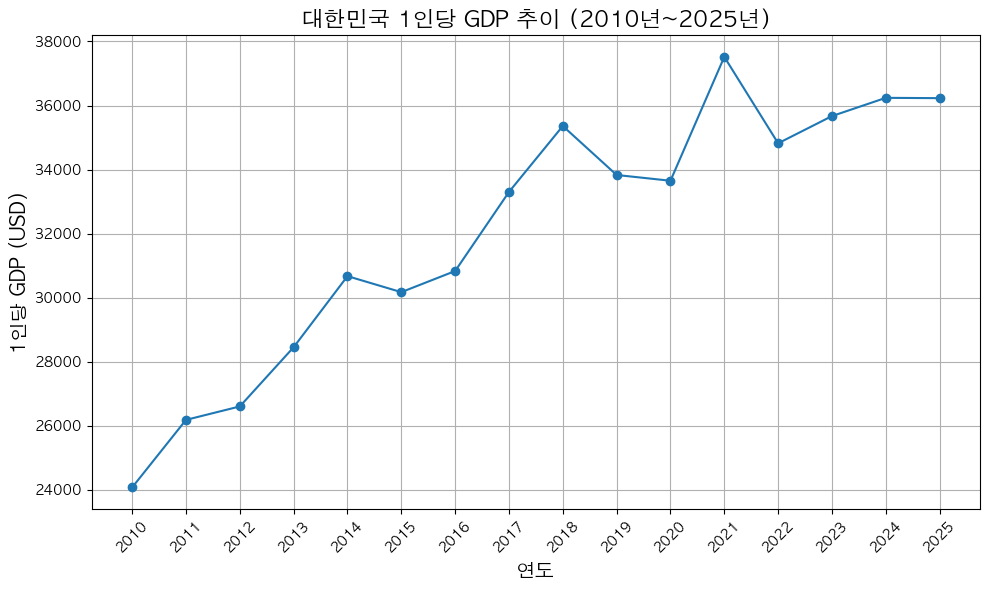


--- [chart_generator] ---
FINAL ANSWER

The graph of South Korea's GDP per capita from 2010 to 2025 has been successfully created and visualized.


In [11]:
# ---------------------------------------------------
# 협업 그래프 실행
# ---------------------------------------------------
# config: 실행 설정
# - recursion_limit: 최대 재귀 횟수 (에이전트 왕복 횟수 제한)
# - thread_id: 대화 스레드 ID (MemorySaver와 함께 사용)
from langchain_core.runnables import RunnableConfig
from langchain.messages import HumanMessage

# 실행 설정
config = RunnableConfig(
    recursion_limit=10,  # 최대 10번 왕복 허용 (너무 높이면 비용 증가)
    configurable={"thread_id": "thread-1"},  # 대화 스레드 ID
)

# 사용자 입력 메시지
inputs = {
    "messages": [
        HumanMessage(
            content="2010년 ~ 2025년까지의 대한민국의 1인당 GDP 추이를 그래프로 시각화 해주세요."
        )
    ],
}

# 스트리밍으로 그래프 실행 (각 노드의 업데이트를 순서대로 출력)
# ============================================================
# 협업 에이전트 실행 시작
# 질문: 2010~2025 한국 1인당 GDP 추이 시각화
# ============================================================

for chunk in app.stream(inputs, config, stream_mode="updates"):
    # 각 노드의 업데이트 출력
    for node_name, node_output in chunk.items():
        print(f"\n--- [{node_name}] ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                # 메시지 내용 요약 출력 (너무 길면 300자까지만)
                content = msg.content
                if isinstance(content, list):
                    content = " ".join(
                        block.get("text", "") for block in content if isinstance(block, dict)
                    )
                preview = content[:300] + "..." if len(content) > 300 else content
                print(preview)

## 8. 실행 결과 분석

그래프 실행 후 최종 상태를 조회해서 전체 대화 히스토리를 확인해볼게요.

각 메시지의 `name` 필드를 보면 어떤 에이전트가 보낸 메시지인지 알 수 있어요.

> 🎯 **강의 포인트**: `app.get_state(config).values["messages"]`로 전체 대화 히스토리를 조회할 수 있어요. 협업 에이전트들이 공유한 메시지들이 시간 순서대로 쌓여 있어요. 각 메시지의 `name` 속성이 발신자를 표시해요. 이것이 "공유 메시지 큐" 패턴의 핵심이에요.

In [12]:
# ---------------------------------------------------
# 실행 결과 분석
# ---------------------------------------------------
# get_state: 현재 그래프 상태 조회 (MemorySaver에 저장된 체크포인트)
# 전체 대화 히스토리를 메시지별로 분석해요

final_state = app.get_state(config)
messages = final_state.values["messages"]

# ============================================================
print(f"전체 대화 메시지 수: {len(messages)}")
# ============================================================

for i, msg in enumerate(messages, 1):
    # 메시지 발신자 정보 추출
    sender = getattr(msg, 'name', None) or msg.__class__.__name__
    content = msg.content

    # content가 리스트인 경우 텍스트 추출
    if isinstance(content, list):
        content = " ".join(
            block.get("text", "") for block in content if isinstance(block, dict)
        )

    # 메시지 요약 (최대 150자)
    preview = content[:150] + "..." if len(content) > 150 else content
    print(f"[{i}] {sender}: {preview}")
    print()

# ------------------------------------------------------------
# 협업 완료!

전체 대화 메시지 수: 3
[1] HumanMessage: 2010년 ~ 2025년까지의 대한민국의 1인당 GDP 추이를 그래프로 시각화 해주세요.

[2] researcher: I cannot create a graph directly, but I can provide you with the data in a format that you can easily visualize using a charting tool or software. Her...

[3] chart_generator: FINAL ANSWER

The graph of South Korea's GDP per capita from 2010 to 2025 has been successfully created and visualized.



## 9. 실습 해설: 협업 에이전트 커스터마이징

아래 완성 예제는 새로운 주제로 Researcher와 Chart Generator가 협업하는 실행 흐름을 보여줘요.

질문: 최근 5년간 미국, 중국, 한국의 GDP 성장률을 비교 막대 그래프로 시각화해주세요


--- [researcher] ---
이제 미국, 중국, 한국의 최근 5년간 GDP 성장률 데이터를 수집하였습니다. 이를 기반으로 비교 막대 그래프를 생성할 준비를 하겠습니다. 각 국의 GDP 성장률은 다음과 같습니다.

### USDA 업데이트된 GDP 성장률 (2021-2025)
- **미국**
  - 2021: 5.7%
  - 2022: 4.0%
  - 2023: 2.1%
  - 2024: 1.4%
  - 2025: 2.0%

- **중국**
  - 2021: 8.1%
  - 2022: 3.0%
  - 2023: 5.0%
  - 2024: 4.5%
  - 2025: 5.5%

- **한국**
  - 2021: 4.0%
  - 2022: 2.6%
  - 2023: 1.0%
  - 2024: 3.2%
  - 2025: 1.2%

이 데이터를 기반으로 그래프를 생성하겠습니다.


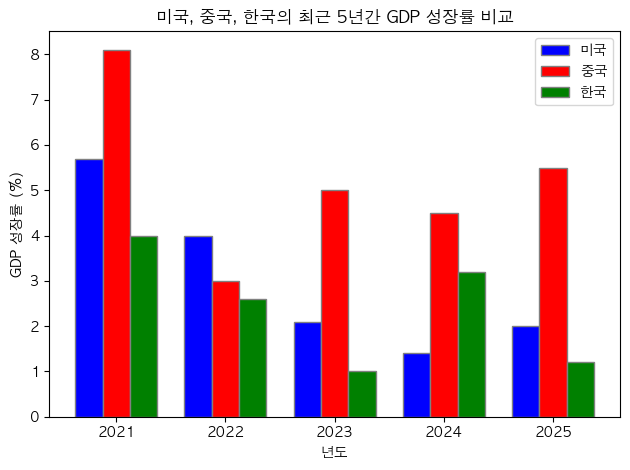


--- [chart_generator] ---
FINAL ANSWER

그래프가 성공적으로 생성되었습니다. 미국, 중국, 한국의 최근 5년간 GDP 성장률을 비교한 막대 그래프를 확인할 수 있습니다.

협업 메시지 수: 3


In [13]:
# ============================================================
# 실습 해설: 다른 주제로 협업 에이전트를 실행해요
#
# 예상 결과: Researcher가 데이터를 수집하고,
#           Chart Generator가 matplotlib으로 차트를 생성해요.
# ============================================================

my_question = "최근 5년간 미국, 중국, 한국의 GDP 성장률을 비교 막대 그래프로 시각화해주세요"

my_config = RunnableConfig(
    recursion_limit=10,
    configurable={"thread_id": "thread-practice-gdp-growth"},
)

print(f"질문: {my_question}\n")

for chunk in app.stream(
    {"messages": [HumanMessage(content=my_question)]},
    my_config,
    stream_mode="updates",
):
    for node_name, node_output in chunk.items():
        print(f"\n--- [{node_name}] ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                content = msg.content
                if isinstance(content, list):
                    content = " ".join(
                        block.get("text", "") for block in content if isinstance(block, dict)
                    )
                print(str(content)[:500])

practice_state = app.get_state(my_config).values
print(f"\n협업 메시지 수: {len(practice_state['messages'])}")

## 10. Supervisor 패턴 vs 협업 패턴 심화 비교

두 패턴을 실제 사용 기준으로 비교해볼게요.

### 언제 협업 패턴을 선택할까요?

```mermaid
flowchart TD
    Q1{에이전트 간<br>긴밀한 반복 협력이<br>필요한가?}
    Q2{중앙 조정자가<br>필요한가?}
    Q3{역할 분담이<br>명확한가?}
    
    A1[협업 패턴 권장<br>에이전트끼리 직접 소통]
    A2[Supervisor 패턴 권장<br>중앙 조정자가 관리]
    A3[협업 패턴도 가능<br>FINAL ANSWER로 종료]

    Q1 -- Yes --> A1
    Q1 -- No --> Q2
    Q2 -- Yes --> A2
    Q2 -- No --> Q3
    Q3 -- Yes --> A3

    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef decision fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef result fill:#d4edda,stroke:#28a745,color:#155724

    class Q1,Q2,Q3 decision
    class A1,A2,A3 result
```

### 실제 적용 사례

| 시나리오 | 적합한 패턴 | 이유 |
|----------|-------------|------|
| **데이터 수집 → 시각화** | 협업 패턴 | 연구자-시각화 전문가 긴밀 협력 |
| **고객 지원 라우팅** | Supervisor 패턴 | 명확한 위임 및 복귀 필요 |
| **보고서 작성** | 협업 패턴 | 조사-작성-검토 반복 개선 |
| **코드 리뷰** | 협업 패턴 | 작성-리뷰-수정 사이클 |
| **다중 전문가 의견** | Supervisor 패턴 | 각 전문가 독립 의견 취합 |

> 🔑 **핵심 개념**: 두 패턴은 상호 배타적이지 않아요. **Supervisor + 협업 에이전트 하이브리드**도 가능해요. 예를 들어 Supervisor가 상위 조정을 하고, 특정 서브태스크는 협업 에이전트들이 처리하는 구조예요.

In [14]:
# ---------------------------------------------------
# 패턴 비교 요약 코드
# ---------------------------------------------------
# 두 패턴의 핵심 구성 요소를 코드 관점에서 비교해요

# Supervisor 패턴 vs 협업 패턴 코드 비교
# ============================================================

supervisor_key = """
# Supervisor 패턴 핵심
- create_supervisor(agents=[...])  # 중앙 조정자 자동 생성
- create_handoff_tool(agent_name=...)  # 단방향 핸드오프
- Command(goto=agent, graph=PARENT)  # 에이전트로 제어권 이전
- add_edge("agent", "supervisor")  # 에이전트 → Supervisor 복귀
"""

collaboration_key = """
# 협업 패턴 핵심  
- make_system_prompt(suffix)  # 협업 지시사항 통합
- HumanMessage(name="researcher")  # 발신자 표시
- add_conditional_edges(router)  # FINAL ANSWER로 종료 결정
- recursion_limit=10  # 무한 루프 방지
"""

print("[Supervisor 패턴]", supervisor_key)
print("[협업 패턴]", collaboration_key)

[Supervisor 패턴] 
# Supervisor 패턴 핵심
- create_supervisor(agents=[...])  # 중앙 조정자 자동 생성
- create_handoff_tool(agent_name=...)  # 단방향 핸드오프
- Command(goto=agent, graph=PARENT)  # 에이전트로 제어권 이전
- add_edge("agent", "supervisor")  # 에이전트 → Supervisor 복귀

[협업 패턴] 
# 협업 패턴 핵심  
- make_system_prompt(suffix)  # 협업 지시사항 통합
- HumanMessage(name="researcher")  # 발신자 표시
- add_conditional_edges(router)  # FINAL ANSWER로 종료 결정
- recursion_limit=10  # 무한 루프 방지



## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **협업 패턴**: Supervisor 없이 에이전트들이 `MessagesState`를 공유하며 직접 소통하는 분산 협력 방식이에요
- **make_system_prompt()**: 팀원 인식 + `"FINAL ANSWER"` 신호 방법을 포함한 공통 협업 지시사항 헬퍼 함수예요
- **HumanMessage(name=...)**: 에이전트 응답을 HumanMessage로 변환할 때 `name` 파라미터로 발신자를 표시해요. 파트너 에이전트가 메시지를 사용자 입력처럼 자연스럽게 받을 수 있어요
- **router 함수**: 에이전트 출력에서 `"FINAL ANSWER"` 키워드를 감지해 그래프 종료(`END`) 또는 파트너 에이전트로 전달(`"continue"`)을 결정해요
- **add_conditional_edges**: 라우터 함수 결과에 따라 분기하는 조건부 엣지로 양방향 순환 그래프를 구성해요
- **recursion_limit**: 협업 에이전트의 무한 루프를 방지하는 필수 안전장치예요. `RunnableConfig(recursion_limit=10)`로 설정해요
- **Supervisor vs 협업**: Supervisor는 명확한 위계가 필요할 때, 협업 패턴은 에이전트 간 반복적인 협력이 필요할 때 적합해요

## 다음 노트북 예고

다음 `04-Multi-Agent-Supervisor.ipynb`에서는 **다중 전문가 Supervisor** 패턴을 배워요. 더 많은 전문 에이전트와 복잡한 작업 분배를 Supervisor가 어떻게 조정하는지 살펴볼게요.